# DAY 1 — NOTEBOOK 1: Download & First Look at Data

## What this notebook does:
1. Downloads the Telco Churn dataset automatically
2. Loads it into pandas
3. Shows you what the data looks like
4. Checks for problems (missing values, wrong types)
5. Saves your findings to a notes file

## Run each cell ONE BY ONE from top to bottom

---
## CELL 1 — Import Libraries
**What this does:** Loads all the tools we need
- `pandas` = tool for working with tables of data
- `numpy` = tool for math calculations
- `matplotlib/seaborn` = tools for making charts
- `os` = tool for working with files and folders

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Makes charts look nice and big
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## CELL 2 — Download the Dataset Automatically
**What this does:** Downloads the Telco Churn CSV file directly from the internet
and saves it to your `data/raw/` folder

**IMPORTANT:** `data/raw/` is sacred — we NEVER modify files here.
This is the original data, always kept safe.

In [6]:
import urllib.request

# Where to save the file
RAW_DATA_PATH = 'data/raw/telco_churn.csv'

# Dataset URL (publicly available IBM dataset)
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

# Download only if file doesn't already exist
if not os.path.exists(RAW_DATA_PATH):
    print('Downloading dataset...')
    urllib.request.urlretrieve(URL, RAW_DATA_PATH)
    print(f'✅ Dataset downloaded and saved to: {RAW_DATA_PATH}')
else:
    print(f'✅ Dataset already exists at: {RAW_DATA_PATH}')

✅ Dataset downloaded and saved to: data/raw/telco_churn.csv


---
## CELL 3 — Load the Data
**What this does:** Reads the CSV file into a pandas DataFrame.
A DataFrame is like an Excel table inside Python — rows and columns.

In [7]:
# Load CSV into a DataFrame called 'df'
df = pd.read_csv(RAW_DATA_PATH)

# Shape tells us: (number of rows, number of columns)
print(f'Dataset Shape: {df.shape}')
print(f'Total Customers: {df.shape[0]}')
print(f'Total Features (columns): {df.shape[1]}')
print()
print('✅ Data loaded successfully!')

Dataset Shape: (7043, 21)
Total Customers: 7043
Total Features (columns): 21

✅ Data loaded successfully!


---
## CELL 4 — First Look: What Does the Data Look Like?
**What this does:** Shows the first 5 rows of the dataset.
Like opening an Excel file and seeing the top rows.

In [8]:
print('=== FIRST 5 ROWS OF DATA ===')
print('(Each row = one customer)')
print()
df.head()

=== FIRST 5 ROWS OF DATA ===
(Each row = one customer)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## CELL 5 — What Columns Do We Have?
**What this does:** Lists every column with its data type.
- `object` = text (like Yes/No, Male/Female)
- `int64` = whole numbers (like 0, 1, 2)
- `float64` = decimal numbers (like 29.85, 100.50)

In [9]:
print('=== ALL COLUMNS AND THEIR TYPES ===')
print()

for col in df.columns:
    dtype = df[col].dtype
    sample = df[col].iloc[0]
    print(f'  {col:<25} | Type: {str(dtype):<10} | Example: {sample}')

=== ALL COLUMNS AND THEIR TYPES ===

  customerID                | Type: object     | Example: 7590-VHVEG
  gender                    | Type: object     | Example: Female
  SeniorCitizen             | Type: int64      | Example: 0
  Partner                   | Type: object     | Example: Yes
  Dependents                | Type: object     | Example: No
  tenure                    | Type: int64      | Example: 1
  PhoneService              | Type: object     | Example: No
  MultipleLines             | Type: object     | Example: No phone service
  InternetService           | Type: object     | Example: DSL
  OnlineSecurity            | Type: object     | Example: No
  OnlineBackup              | Type: object     | Example: Yes
  DeviceProtection          | Type: object     | Example: No
  TechSupport               | Type: object     | Example: No
  StreamingTV               | Type: object     | Example: No
  StreamingMovies           | Type: object     | Example: No
  Contract           

---
## CELL 6 — Understand What Each Column Means
**What this does:** Prints a clear explanation of every column.
This is your data dictionary — understand your data before touching it.

In [10]:
# Dictionary explaining every column in plain English
column_explanations = {
    'customerID':        'Unique ID for each customer — NOT useful for prediction',
    'gender':            'Male or Female',
    'SeniorCitizen':     '1 = senior citizen (65+), 0 = not senior',
    'Partner':           'Has a partner? Yes/No',
    'Dependents':        'Has dependents (children etc.)? Yes/No',
    'tenure':            'How many MONTHS they have been a customer — very important!',
    'PhoneService':      'Has phone service? Yes/No',
    'MultipleLines':     'Has multiple phone lines? Yes/No/No phone service',
    'InternetService':   'Type of internet: DSL, Fiber optic, or No internet',
    'OnlineSecurity':    'Has online security addon? Yes/No',
    'OnlineBackup':      'Has online backup addon? Yes/No',
    'DeviceProtection':  'Has device protection? Yes/No',
    'TechSupport':       'Has tech support? Yes/No',
    'StreamingTV':       'Streams TV? Yes/No',
    'StreamingMovies':   'Streams movies? Yes/No',
    'Contract':          'Contract type: Month-to-month, One year, Two year — very important!',
    'PaperlessBilling':  'Uses paperless billing? Yes/No',
    'PaymentMethod':     'How they pay: Electronic check, Mailed check, Bank transfer, Credit card',
    'MonthlyCharges':    'How much they pay per month — very important!',
    'TotalCharges':      'Total amount paid over entire time as customer',
    'Churn':             '*** THIS IS WHAT WE PREDICT *** Yes = left, No = stayed'
}

print('=== WHAT EACH COLUMN MEANS ===')
print()
for col, explanation in column_explanations.items():
    marker = '🎯' if col == 'Churn' else '  '
    print(f'{marker} {col:<22}: {explanation}')

=== WHAT EACH COLUMN MEANS ===

   customerID            : Unique ID for each customer — NOT useful for prediction
   gender                : Male or Female
   SeniorCitizen         : 1 = senior citizen (65+), 0 = not senior
   Partner               : Has a partner? Yes/No
   Dependents            : Has dependents (children etc.)? Yes/No
   tenure                : How many MONTHS they have been a customer — very important!
   PhoneService          : Has phone service? Yes/No
   MultipleLines         : Has multiple phone lines? Yes/No/No phone service
   InternetService       : Type of internet: DSL, Fiber optic, or No internet
   OnlineSecurity        : Has online security addon? Yes/No
   OnlineBackup          : Has online backup addon? Yes/No
   DeviceProtection      : Has device protection? Yes/No
   TechSupport           : Has tech support? Yes/No
   StreamingTV           : Streams TV? Yes/No
   StreamingMovies       : Streams movies? Yes/No
   Contract              : Contract type

---
## CELL 7 — Check Our Target: How Many Customers Churned?
**What this does:** Shows how many customers left vs stayed.
This is CRITICAL — if very few churned, the model will be biased.

=== CHURN DISTRIBUTION ===

  Customers who STAYED (No):  5,174  (73.5%)
  Customers who LEFT  (Yes): 1,869  (26.5%)

⚠️  IMPORTANT FINDING:
   Only 27% of customers churned.
   This is called CLASS IMBALANCE.
   If we do nothing, model will just predict No for everyone!
   We must fix this later in Day 5-6.


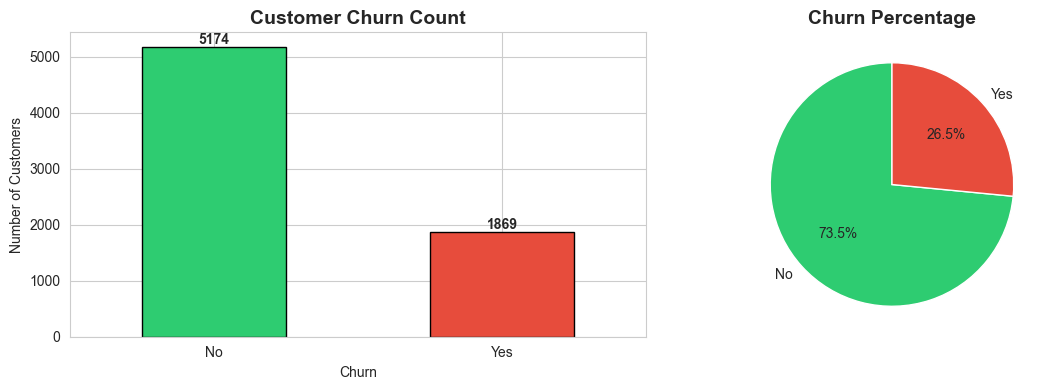

✅ Chart saved to docs/churn_distribution.png


In [12]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== CHURN DISTRIBUTION ===')
print()
print(f"  Customers who STAYED (No):  {churn_counts['No']:,}  ({churn_pct['No']:.1f}%)")
print(f"  Customers who LEFT  (Yes): {churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)")
print()
print('⚠️  IMPORTANT FINDING:')
print(f'   Only {churn_pct["Yes"]:.0f}% of customers churned.')
print('   This is called CLASS IMBALANCE.')
print('   If we do nothing, model will just predict No for everyone!')
print('   We must fix this later in Day 5-6.')

# Visual chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
churn_counts.plot(kind='pie', ax=axes[1], colors=['#2ecc71', '#e74c3c'],
                  autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('docs/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to docs/churn_distribution.png')

---
## CELL 8 — Check for Missing Values
**What this does:** Finds every column that has empty/missing values.
Missing values = blank cells in Excel. ML models CANNOT handle blanks.

In [13]:
print('=== MISSING VALUES CHECK ===')
print()

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Only show columns that actually have missing values
missing_found = missing_df[missing_df['Missing Count'] > 0]

if len(missing_found) == 0:
    print('✅ No missing values found in any column!')
    print()
    print('BUT WAIT — check TotalCharges carefully in the next cell...')
else:
    print(f'⚠️  Found {len(missing_found)} columns with missing values:')
    print(missing_found)

print()
print('Total rows in dataset:', len(df))

=== MISSING VALUES CHECK ===

✅ No missing values found in any column!

BUT WAIT — check TotalCharges carefully in the next cell...

Total rows in dataset: 7043


---
## CELL 9 — Find the Hidden Problem in TotalCharges
**What this does:** The dataset LOOKS clean but TotalCharges has a sneaky problem.
Some values are spaces ' ' instead of actual numbers.
This is a real-world data quality issue — exactly what jobs test you on!

In [14]:
print('=== HIDDEN PROBLEM IN TotalCharges ===')
print()
print(f"Current data type of TotalCharges: {df['TotalCharges'].dtype}")
print('Expected: float64 (a number)')
print('Actual: object (text!)')
print()

# Find rows where TotalCharges is just a space
problem_rows = df[df['TotalCharges'].str.strip() == '']
print(f'Number of rows with blank TotalCharges: {len(problem_rows)}')
print()

if len(problem_rows) > 0:
    print('These are the problem rows:')
    print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
    print()
    print('NOTICE: These customers have tenure=0 (brand new customers)')
    print('They have no total charges yet because they just signed up!')
    print()
    print('FIX PLAN: Replace blank TotalCharges with 0 for new customers')
    print('We will do this fix in Day 3-4 notebooks.')

=== HIDDEN PROBLEM IN TotalCharges ===

Current data type of TotalCharges: object
Expected: float64 (a number)
Actual: object (text!)

Number of rows with blank TotalCharges: 11

These are the problem rows:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

NOTICE: These customers have tenure=0 (brand new customers)
They have no

---
## CELL 10 — Check All Unique Values in Text Columns
**What this does:** Shows every unique value in text columns.
This helps us understand what options exist and catch typos or weird values.

In [15]:
print('=== UNIQUE VALUES IN TEXT COLUMNS ===')
print('(Important: check if values make sense)')
print()

text_columns = df.select_dtypes(include='object').columns.tolist()

for col in text_columns:
    unique_vals = df[col].unique()
    print(f'  {col:<22}: {list(unique_vals)}')

=== UNIQUE VALUES IN TEXT COLUMNS ===
(Important: check if values make sense)

  customerID            : ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU'

---
## CELL 11 — Basic Statistics for Number Columns
**What this does:** Shows min, max, average for all number columns.
Look for anything that seems wrong (like negative age, charges = 0, etc.)

In [16]:
print('=== STATISTICS FOR NUMBER COLUMNS ===')
print()
print(df.describe().round(2))
print()
print('What to look for:')
print('  - tenure: min=0, max should be around 72 months (6 years)')
print('  - MonthlyCharges: should be between $18 and $120')
print('  - SeniorCitizen: only 0 or 1 (binary)')

=== STATISTICS FOR NUMBER COLUMNS ===

       SeniorCitizen   tenure  MonthlyCharges
count        7043.00  7043.00         7043.00
mean            0.16    32.37           64.76
std             0.37    24.56           30.09
min             0.00     0.00           18.25
25%             0.00     9.00           35.50
50%             0.00    29.00           70.35
75%             0.00    55.00           89.85
max             1.00    72.00          118.75

What to look for:
  - tenure: min=0, max should be around 72 months (6 years)
  - MonthlyCharges: should be between $18 and $120
  - SeniorCitizen: only 0 or 1 (binary)


---
## CELL 12 — Visualize Number Distributions
**What this does:** Creates charts showing the spread of numerical values.
Helps spot outliers (extreme values) and understand patterns.

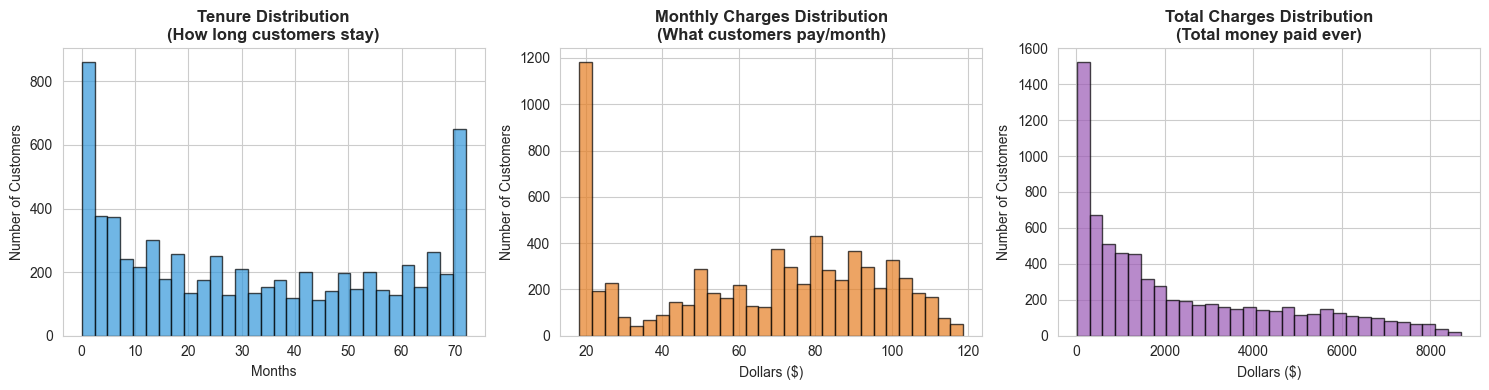

✅ Chart saved to docs/numerical_distributions.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure distribution
axes[0].hist(df['tenure'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Tenure Distribution\n(How long customers stay)', fontweight='bold')
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Number of Customers')

# Monthly Charges
axes[1].hist(df['MonthlyCharges'], bins=30, color='#e67e22', edgecolor='black', alpha=0.7)
axes[1].set_title('Monthly Charges Distribution\n(What customers pay/month)', fontweight='bold')
axes[1].set_xlabel('Dollars ($)')
axes[1].set_ylabel('Number of Customers')

# TotalCharges (convert first)
tc = pd.to_numeric(df['TotalCharges'], errors='coerce').dropna()
axes[2].hist(tc, bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[2].set_title('Total Charges Distribution\n(Total money paid ever)', fontweight='bold')
axes[2].set_xlabel('Dollars ($)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('docs/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to docs/numerical_distributions.png')

---
## CELL 13 — Compare Churned vs Stayed Customers
**What this does:** Shows HOW DIFFERENT churned customers look vs ones who stayed.
This is the most important exploration — finding patterns in who leaves.

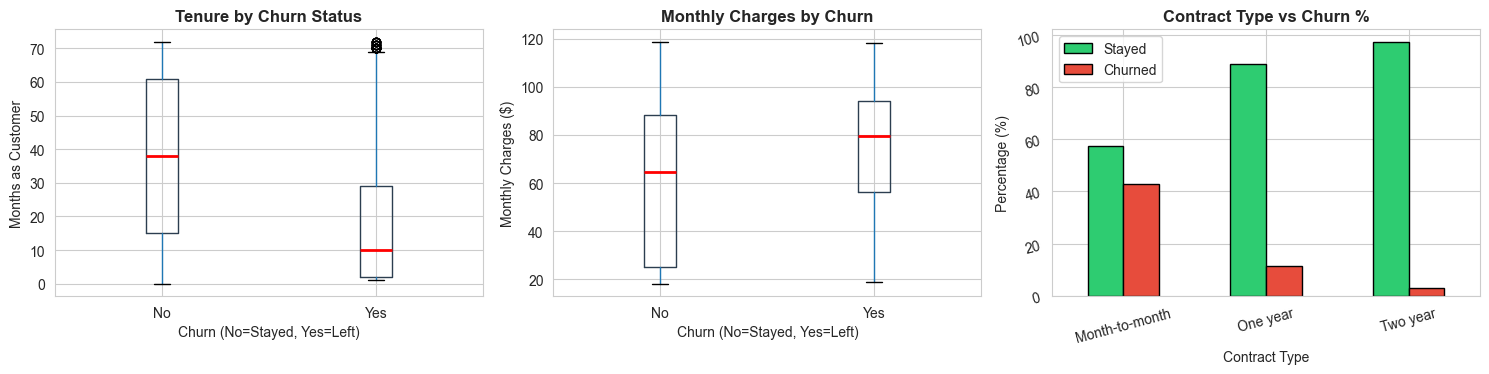

✅ Chart saved to docs/churn_patterns.png

KEY INSIGHTS FROM THIS CHART:
  1. Churned customers have LOWER tenure — they leave early
  2. Churned customers pay HIGHER monthly charges
  3. Month-to-month contracts churn MUCH more than 1 or 2 year contracts


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure by Churn
df.boxplot(column='tenure', by='Churn', ax=axes[0],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Tenure by Churn Status', fontweight='bold')
axes[0].set_xlabel('Churn (No=Stayed, Yes=Left)')
axes[0].set_ylabel('Months as Customer')

# Monthly Charges by Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].set_xlabel('Churn (No=Stayed, Yes=Left)')
axes[1].set_ylabel('Monthly Charges ($)')

# Contract Type by Churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'],
                    edgecolor='black')
axes[2].set_title('Contract Type vs Churn %', fontweight='bold')
axes[2].set_xlabel('Contract Type')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(rotation=15)
axes[2].legend(['Stayed', 'Churned'])

plt.suptitle('')
plt.tight_layout()
plt.savefig('docs/churn_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Chart saved to docs/churn_patterns.png')
print()
print('KEY INSIGHTS FROM THIS CHART:')
print('  1. Churned customers have LOWER tenure — they leave early')
print('  2. Churned customers pay HIGHER monthly charges')
print('  3. Month-to-month contracts churn MUCH more than 1 or 2 year contracts')

---
## CELL 14 — Correlation Heatmap
**What this does:** Shows which columns are related to each other.
Correlation close to 1 or -1 = strong relationship.
Correlation close to 0 = no relationship.

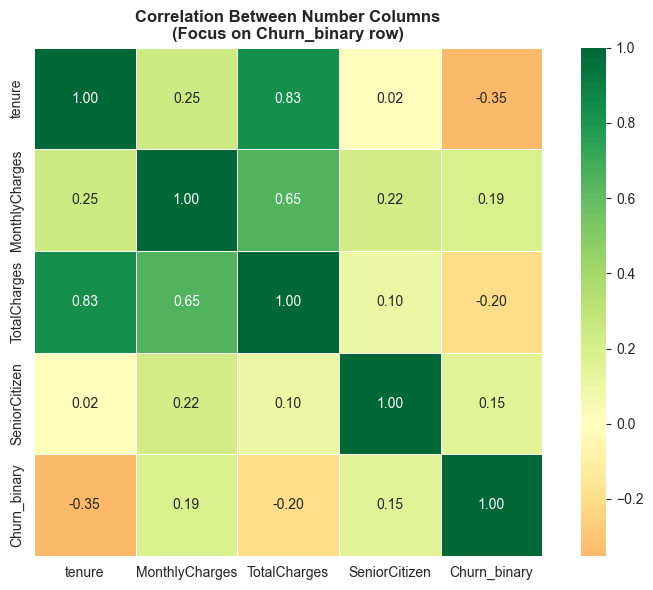

✅ Chart saved to docs/correlation_heatmap.png

HOW TO READ THIS:
  Look at the Churn_binary row:
  - tenure has NEGATIVE correlation = longer customers = less churn
  - MonthlyCharges has POSITIVE correlation = higher charges = more churn


In [22]:
# Only numeric columns for correlation
df_numeric = df.copy()
df_numeric['TotalCharges'] = pd.to_numeric(df_numeric['TotalCharges'], errors='coerce')
df_numeric['Churn_binary'] = (df_numeric['Churn'] == 'Yes').astype(int)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr_matrix = df_numeric[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Between Number Columns\n(Focus on Churn_binary row)', fontweight='bold')
plt.tight_layout()
plt.savefig('docs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Chart saved to docs/correlation_heatmap.png')
print()
print('HOW TO READ THIS:')
print('  Look at the Churn_binary row:')
print('  - tenure has NEGATIVE correlation = longer customers = less churn')
print('  - MonthlyCharges has POSITIVE correlation = higher charges = more churn')

---
## CELL 15 — Save Your Data Notes
**What this does:** Automatically writes all your findings to a notes file.
This is your DATA DOCUMENTATION — real engineers always document what they find.

In [24]:
# Count items for notes
total_rows = len(df)
total_cols = len(df.columns)
churn_yes = len(df[df['Churn'] == 'Yes'])
churn_no = len(df[df['Churn'] == 'No'])
churn_rate = round(churn_yes / total_rows * 100, 1)
blank_charges = len(df[df['TotalCharges'].str.strip() == ''])

notes = f"""==================================================
DATA EXPLORATION NOTES — Day 1
==================================================

DATASET OVERVIEW
----------------
Total Customers   : {total_rows:,}
Total Columns     : {total_cols}
Target Column     : Churn (Yes/No)

CHURN DISTRIBUTION
------------------
Stayed (No)  : {churn_no:,} customers ({100-churn_rate}%)
Churned (Yes): {churn_yes:,} customers ({churn_rate}%)
>> CLASS IMBALANCE EXISTS — must handle in modeling step

DATA QUALITY ISSUES FOUND
-------------------------
1. TotalCharges column:
   - Type is 'object' (text) instead of float
   - {blank_charges} rows have blank spaces instead of numbers
   - These are new customers with tenure=0
   - FIX: Convert to numeric, replace blanks with 0

KEY PATTERNS FOUND
------------------
1. Churned customers have SHORTER tenure (leave early)
2. Churned customers pay HIGHER monthly charges
3. Month-to-month contracts churn most (~42%)
4. Two-year contracts rarely churn (~3%)
5. Fiber optic internet customers churn more

IMPORTANT COLUMNS FOR PREDICTION
---------------------------------
- tenure (how long they've been customer)
- MonthlyCharges (how much they pay)
- Contract (type of contract)
- InternetService (type of internet)
- TechSupport (has support or not)

COLUMNS TO DROP
---------------
- customerID: just an ID, not useful for prediction

NEXT STEPS (Day 3-4)
--------------------
1. Fix TotalCharges column
2. Convert all text columns to numbers
3. Create new features (tenure groups, charge ratios)
4. Build baseline model
==================================================
"""

with open('docs/data_notes.txt', 'w') as f:
    f.write(notes)

print(notes)
print('✅ Notes saved to docs/data_notes.txt')

DATA EXPLORATION NOTES — Day 1

DATASET OVERVIEW
----------------
Total Customers   : 7,043
Total Columns     : 21
Target Column     : Churn (Yes/No)

CHURN DISTRIBUTION
------------------
Stayed (No)  : 5,174 customers (73.5%)
Churned (Yes): 1,869 customers (26.5%)
>> CLASS IMBALANCE EXISTS — must handle in modeling step

DATA QUALITY ISSUES FOUND
-------------------------
1. TotalCharges column:
   - Type is 'object' (text) instead of float
   - 11 rows have blank spaces instead of numbers
   - These are new customers with tenure=0
   - FIX: Convert to numeric, replace blanks with 0

KEY PATTERNS FOUND
------------------
1. Churned customers have SHORTER tenure (leave early)
2. Churned customers pay HIGHER monthly charges
3. Month-to-month contracts churn most (~42%)
4. Two-year contracts rarely churn (~3%)
5. Fiber optic internet customers churn more

IMPORTANT COLUMNS FOR PREDICTION
---------------------------------
- tenure (how long they've been customer)
- MonthlyCharges (how mu

---
## CELL 16 — Day 1 Summary
**What this does:** Recap of everything you did today.

In [25]:
print('==================================================')
print('DAY 1 COMPLETE! HERE IS WHAT YOU ACCOMPLISHED:')
print('==================================================')
print()
print('✅ Downloaded the dataset automatically')
print('✅ Loaded 7,043 customer records into pandas')
print('✅ Understood all 21 columns and what they mean')
print('✅ Found class imbalance (73% stayed, 27% churned)')
print('✅ Found hidden data quality issue in TotalCharges')
print('✅ Discovered key patterns (contract type, tenure, charges)')
print('✅ Created 4 charts saved to docs/ folder')
print('✅ Wrote data documentation to docs/data_notes.txt')
print()
print('TOMORROW (DAY 2): More deep exploration + understanding')
print('Run notebook: 02_deep_exploration.ipynb')
print('==================================================')

DAY 1 COMPLETE! HERE IS WHAT YOU ACCOMPLISHED:

✅ Downloaded the dataset automatically
✅ Loaded 7,043 customer records into pandas
✅ Understood all 21 columns and what they mean
✅ Found class imbalance (73% stayed, 27% churned)
✅ Found hidden data quality issue in TotalCharges
✅ Discovered key patterns (contract type, tenure, charges)
✅ Created 4 charts saved to docs/ folder
✅ Wrote data documentation to docs/data_notes.txt

TOMORROW (DAY 2): More deep exploration + understanding
Run notebook: 02_deep_exploration.ipynb
